# Model 1 — Logistic Regression
**COEN 330 — Applied Machine Learning**

**Validation strategy:** 5-fold Stratified K-Fold on the training set (80%).  
**Primary metric:** Recall on `is_risky=1` — catch as many risky applicants as possible.  
**Test set (20%):** touched only in the final cell for held-out evaluation.

In [14]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, os.path.abspath('../src'))

from utils import SEED, MODELS_DIR, RESULTS_DIR, PLOTS_DIR
from preprocessing import run_full_pipeline
from logistic_regression import train_baseline, tune, cross_validate_model, save_model
from evaluate import evaluate, plot_confusion_matrix, tune_threshold, save_metrics

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path(os.path.abspath('../data/raw/dataset.csv'))

## 1. Load & Preprocess Data

Calls the existing preprocessing pipeline — 80/20 stratified split, preprocessor fit on train only.

In [15]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found at {DATA_PATH}')

X_train, X_test, y_train, y_test, feature_names, preprocessor = run_full_pipeline(str(DATA_PATH))

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Train is_risky=1 : {y_train.mean():.1%}  |  Test is_risky=1 : {y_test.mean():.1%}')

is_risky class balance: {1: 0.778, 0: 0.222}
Preprocessor saved to /Users/poewt/Coding/Machine Learning/Team-1-Project/models/preprocessor.pkl

Split sizes - Train: 36000, Test: 9000
Encoded feature count: 23
Features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'person_education', 'person_gender_female', 'person_gender_male', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'previous_loan_defaults_on_file_No', 'previous_loan_defaults_on_file_Yes']
Train : (36000, 23)  |  Test : (9000, 23)
Train is_risky=1 : 77.8%  |  Test is_risky=1 : 77.8%


## 2. Baseline Model

Default LogisticRegression (C=1, L2, threshold=0.5) — no tuning.  
This is our reference point. We run 5-fold CV to get a stable estimate of its performance.

In [16]:
baseline = train_baseline(X_train, y_train)

baseline_cv = cross_validate_model(baseline, X_train, y_train, cv_folds=5)

print('Baseline — 5-Fold CV results on training set:')
for metric, vals in baseline_cv.items():
    print(f"  {metric:<14} mean={vals['mean']:.4f}  std={vals['std']:.4f}  folds={[f'{v:.3f}' for v in vals['folds']]}")

Baseline — 5-Fold CV results on training set:
  accuracy       mean=0.8987  std=0.0044  folds=['0.904', '0.891', '0.897', '0.898', '0.902']
  recall_1       mean=0.9379  std=0.0054  folds=['0.942', '0.929', '0.939', '0.935', '0.945']
  precision_1    mean=0.9323  std=0.0022  folds=['0.935', '0.931', '0.930', '0.935', '0.931']
  f1_1           mean=0.9351  std=0.0030  folds=['0.938', '0.930', '0.934', '0.935', '0.938']


## 3. Hyperparameter Tuning

GridSearchCV over `C` ∈ {0.001, 0.01, 0.1, 1, 10, 100} × penalty ∈ {L1, L2}.  
5-fold Stratified K-Fold on the training set — the test set is never used for selection.

In [17]:
tuned_model, cv_results = tune(X_train, y_train, cv_folds=5)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params : {'C': 0.001, 'l1_ratio': 1, 'max_iter': 2000, 'solver': 'saga'}
Best CV recall (is_risky=1): 0.9734


In [18]:
# Top 10 configurations by mean CV recall
cols = ['param_C', 'param_l1_ratio', 'mean_test_score', 'std_test_score', 'rank_test_score']
cv_results[cols].sort_values('rank_test_score').head(10).reset_index(drop=True)

,param_C,param_l1_ratio,mean_test_score,std_test_score,rank_test_score
0,0.001,1,0.973429,0.003153,1
1,0.001,0,0.967929,0.004056,2
2,0.010,0,0.944071,0.004886,3
3,0.010,1,0.940536,0.005466,4
4,0.100,0,0.938679,0.005436,5
5,0.100,1,0.938107,0.005181,6
6,1.000,0,0.937857,0.005446,7
7,1.000,1,0.937821,0.005355,8
8,10.000,1,0.937821,0.005441,8
9,10.000,0,0.937786,0.005395,10


## 4. Cross-Validate the Tuned Model

Re-run CV with the best hyperparameters to report per-fold stability — goes into the report.

In [19]:
tuned_cv = cross_validate_model(tuned_model, X_train, y_train, cv_folds=5)

print('Tuned LR — 5-Fold CV results on training set:')
for metric, vals in tuned_cv.items():
    print(f"  {metric:<14} mean={vals['mean']:.4f}  std={vals['std']:.4f}  folds={[f'{v:.3f}' for v in vals['folds']]}")

Tuned LR — 5-Fold CV results on training set:
  accuracy       mean=0.8721  std=0.0034  folds=['0.876', '0.867', '0.870', '0.872', '0.876']
  recall_1       mean=0.9734  std=0.0032  folds=['0.977', '0.969', '0.971', '0.974', '0.976']
  precision_1    mean=0.8760  std=0.0014  folds=['0.877', '0.874', '0.876', '0.875', '0.878']
  f1_1           mean=0.9221  std=0.0021  folds=['0.924', '0.919', '0.921', '0.922', '0.925']


## 5. Threshold Tuning

The default 0.5 threshold is not optimal when recall is the priority.  
We sweep thresholds on the **training set CV predictions** to pick one that achieves ≥85% recall while maximising precision.  
This threshold is then applied consistently to the test set.

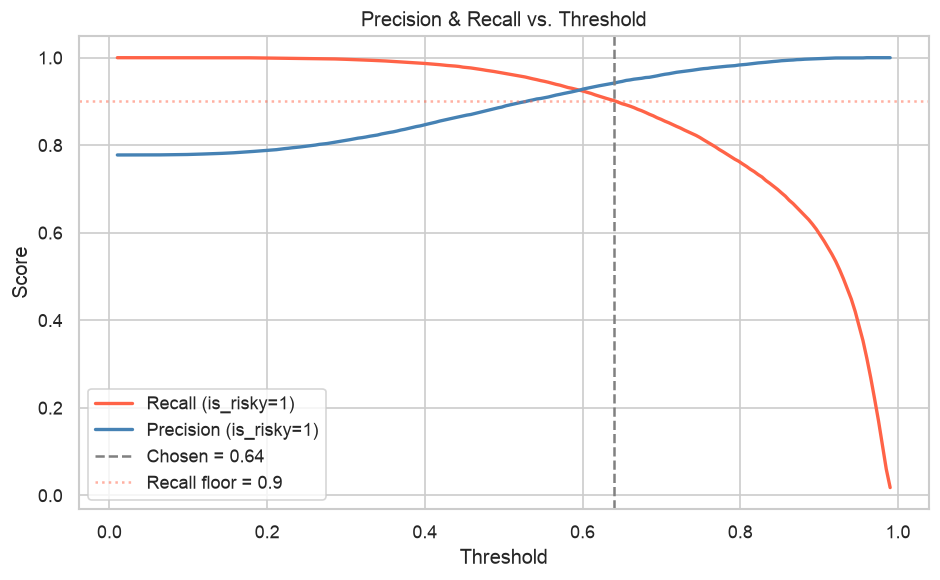

Chosen threshold: 0.64


In [27]:
best_threshold = tune_threshold(
    tuned_model, X_train, y_train,
    min_recall=0.90,
    save_path=str(PLOTS_DIR / 'lr_threshold_tuning.png')
)

## 6. Final Evaluation on the Held-Out Test Set

> The test set is used **once** here — not for tuning, not for threshold selection.

In [29]:
# Default threshold
test_metrics_05 = evaluate(
    tuned_model, X_test, y_test,
    threshold=0.5,
    label='Tuned LR — Test — threshold=0.50'
)

--- Tuned LR — Test — threshold=0.50 ---
Threshold: 0.50
              precision    recall  f1-score   support

    Safe (0)       0.81      0.57      0.67      2000
   Risky (1)       0.89      0.96      0.92      7000

    accuracy                           0.87      9000
   macro avg       0.85      0.77      0.80      9000
weighted avg       0.87      0.87      0.87      9000



In [30]:
# Tuned threshold
test_metrics = evaluate(
    tuned_model, X_test, y_test,
    threshold=best_threshold,
    label=f'Tuned LR — Test — threshold={best_threshold:.2f}'
)

--- Tuned LR — Test — threshold=0.64 ---
Threshold: 0.64
              precision    recall  f1-score   support

    Safe (0)       0.69      0.80      0.74      2000
   Risky (1)       0.94      0.90      0.92      7000

    accuracy                           0.87      9000
   macro avg       0.81      0.85      0.83      9000
weighted avg       0.88      0.87      0.88      9000



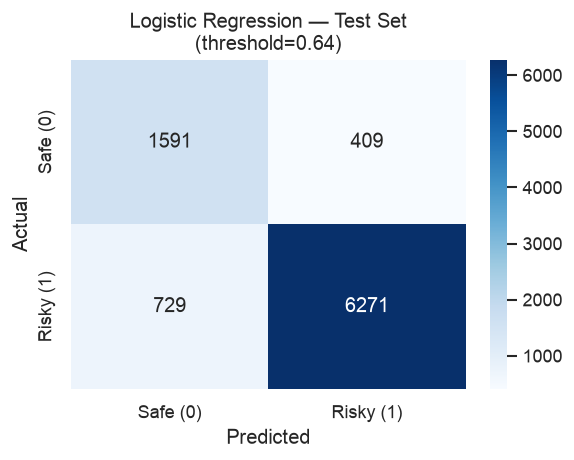

In [31]:
plot_confusion_matrix(
    tuned_model, X_test, y_test,
    threshold=best_threshold,
    title='Logistic Regression — Test Set',
    save_path=str(PLOTS_DIR / 'lr_confusion_matrix.png')
)

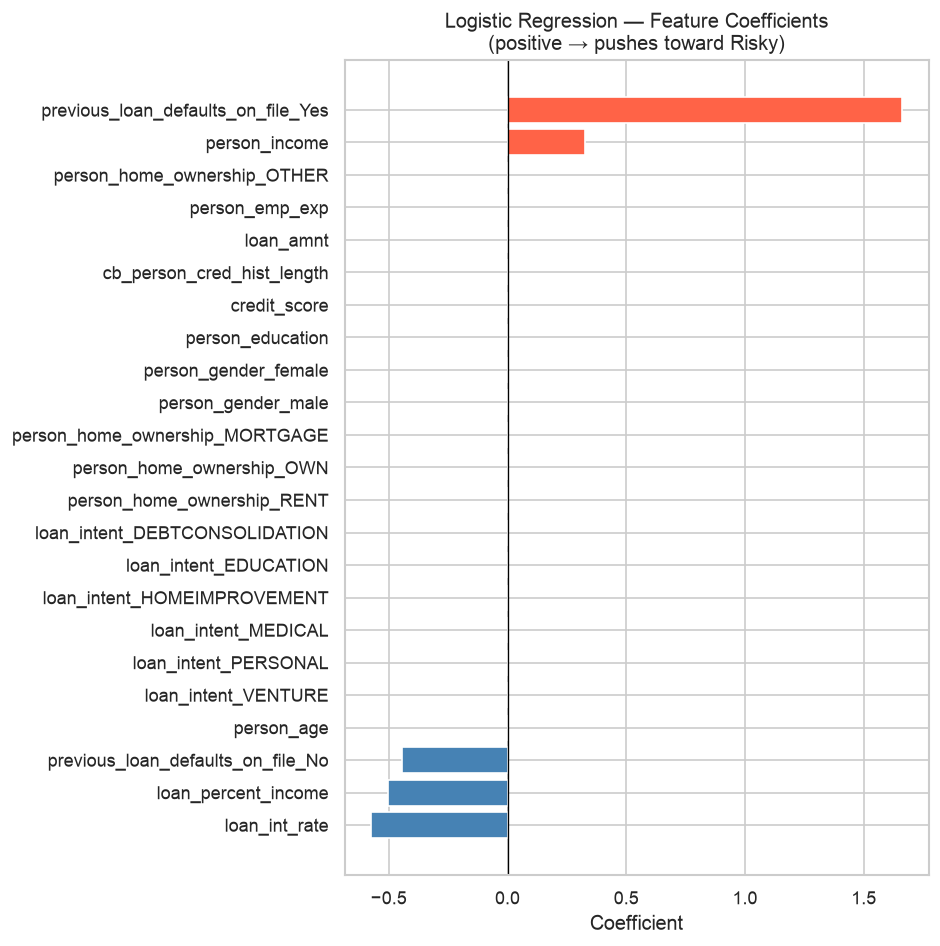

                           feature  coefficient
                     loan_int_rate    -0.574548
               loan_percent_income    -0.502579
 previous_loan_defaults_on_file_No    -0.445180
                        person_age     0.000000
               loan_intent_VENTURE     0.000000
              loan_intent_PERSONAL     0.000000
               loan_intent_MEDICAL     0.000000
       loan_intent_HOMEIMPROVEMENT     0.000000
             loan_intent_EDUCATION     0.000000
     loan_intent_DEBTCONSOLIDATION     0.000000
        person_home_ownership_RENT     0.000000
         person_home_ownership_OWN     0.000000
    person_home_ownership_MORTGAGE     0.000000
                person_gender_male     0.000000
              person_gender_female     0.000000
                  person_education     0.000000
                      credit_score     0.000000
        cb_person_cred_hist_length     0.000000
                         loan_amnt     0.000000
                    person_emp_exp     0

In [34]:
coef_df = pd.DataFrame({
    'feature':     feature_names,
    'coefficient': tuned_model.coef_[0]
}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(8, max(4, len(feature_names) * 0.35)))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Logistic Regression — Feature Coefficients\n(positive → pushes toward Risky)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'lr_coefficients.png'))
plt.show()

print(coef_df.to_string(index=False))

## 8. Save Model & Results

In [33]:
save_model(tuned_model)

save_metrics(
    {'model': 'Logistic Regression', 'split': 'test', **test_metrics},
    path=str(RESULTS_DIR / 'metrics_table.csv')
)

Model saved to /Users/poewt/Coding/Machine Learning/Team-1-Project/models/logistic_regression.pkl
Metrics appended to /Users/poewt/Coding/Machine Learning/Team-1-Project/results/metrics_table.csv


## 9. Results Summary

In [35]:
print(f"{'Metric':<22} {'CV (train)':<14} {'Test (0.5)':<14} {f'Test ({best_threshold:.2f})'}")
print('-' * 66)
for key in ['accuracy', 'recall_1', 'precision_1', 'f1_1']:
    cv_val   = tuned_cv.get(key, {}).get('mean', float('nan'))
    t05_val  = test_metrics_05.get(key, float('nan'))
    best_val = test_metrics.get(key, float('nan'))
    print(f'{key:<22} {cv_val:<14.4f} {t05_val:<14.4f} {best_val:.4f}')

Metric                 CV (train)     Test (0.5)     Test (0.64)
------------------------------------------------------------------
accuracy               0.8721         0.8740         0.8736
recall_1               0.9734         0.9606         0.8959
precision_1            0.8760         0.8868         0.9388
f1_1                   0.9221         0.9222         0.9168
